In [1]:
import polars as pl
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from datetime import timedelta
import sys
sys.path.insert(0, "..")

from src.training.splits import make_backtest_folds
from src.training.dataset import prepare_fold, get_feature_cols, ID_COLS, TARGET, CAT_FEATURES

FEATURES_DIR = Path("../data/processed/features")
MODELS_DIR = Path("../models")

plt.style.use("seaborn-v0_8-darkgrid")

In [2]:
model = lgb.Booster(model_file=str(MODELS_DIR / "lgbm_fold_3.txt"))

lf = pl.scan_parquet(FEATURES_DIR / "*.parquet")
dates = lf.select("date").collect()["date"].unique().sort().to_list()
folds = make_backtest_folds(dates)
fold3 = folds[2]

print(f"Fold 3: {fold3}")
print(f"Validation period: {fold3.val_start} to {fold3.val_end}")

Fold 3: Fold 3: train [2011-01-29 : 2016-03-27] gap 28d val [2016-04-25 : 2016-05-22]
Validation period: 2016-04-25 to 2016-05-22


In [4]:
from src.training.splits import get_fold_data

_, val_lf = get_fold_data(lf, fold3)
val_df = val_lf.collect()

feature_cols = get_feature_cols(val_df.columns)

STR_CAT_FEATURES = ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]

with pl.StringCache():
    for col in STR_CAT_FEATURES:
        if col in val_df.columns:
            val_df = val_df.with_columns(
                pl.col(col).cast(pl.Categorical).to_physical().cast(pl.Int32)
            )

if "snap_wday_interaction" in val_df.columns:
    val_df = val_df.with_columns(
        pl.col("snap_wday_interaction").cast(pl.Int32)
    )

X_val = np.asarray(val_df.select(feature_cols).to_numpy(), dtype=np.float32)
y_val = val_df.select(TARGET).to_numpy().ravel()
val_ids = val_df.select("id").to_numpy().ravel()
val_dates = val_df.select("date").to_numpy().ravel()

y_pred = np.clip(model.predict(X_val), 0, None)

print(f"Val shape: {X_val.shape}")
print(f"Feature names (first 5): {feature_cols[:5]}")
print(f"Predictions range: [{y_pred.min():.3f}, {y_pred.max():.3f}]")
print(f"Actuals range: [{y_val.min():.3f}, {y_val.max():.3f}]")

Val shape: (853720, 56)
Feature names (first 5): ['wday', 'month', 'year', 'event_name_1', 'event_type_1']
Predictions range: [0.004, 155.214]
Actuals range: [0.000, 196.000]


In [5]:
def plot_series(
    series_id: str,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    ids: np.ndarray,
    dates: np.ndarray,
    title: str = None,
    ax=None,
):
    mask = ids == series_id
    s_dates = dates[mask]
    s_true = y_true[mask]
    s_pred = y_pred[mask]

    sort_idx = np.argsort(s_dates)
    s_dates = s_dates[sort_idx]
    s_true = s_true[sort_idx]
    s_pred = s_pred[sort_idx]

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4))

    ax.bar(s_dates, s_true, alpha=0.6, label="Actual", color="steelblue", width=0.8)
    ax.plot(s_dates, s_pred, color="tomato", linewidth=2, label="Predicted", marker="o", markersize=4)
    ax.set_title(title or series_id, fontsize=12)
    ax.set_xlabel("Date")
    ax.set_ylabel("Units sold")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

    rmse = np.sqrt(np.mean((s_true - s_pred) ** 2))
    mae = np.mean(np.abs(s_true - s_pred))
    
    # MAPE only where actuals > 0
    nonzero = s_true > 0
    if nonzero.sum() > 0:
        mape = np.mean(np.abs((s_true[nonzero] - s_pred[nonzero]) / s_true[nonzero])) * 100
        print(f"RMSE={rmse:.3f}  MAE={mae:.3f}  MAPE={mape:.1f}%")
        ax.set_title(f"{title or series_id}\nRMSE={rmse:.3f}  MAE={mae:.3f}  MAPE={mape:.1f}%", fontsize=11)
    else:
        print(f"RMSE={rmse:.3f}  MAE={mae:.3f}")
        ax.set_title(f"{title or series_id}\nRMSE={rmse:.3f}  MAE={mae:.3f}", fontsize=11)
    

    return ax

RMSE=14.676  MAE=11.412  MAPE=20.4%


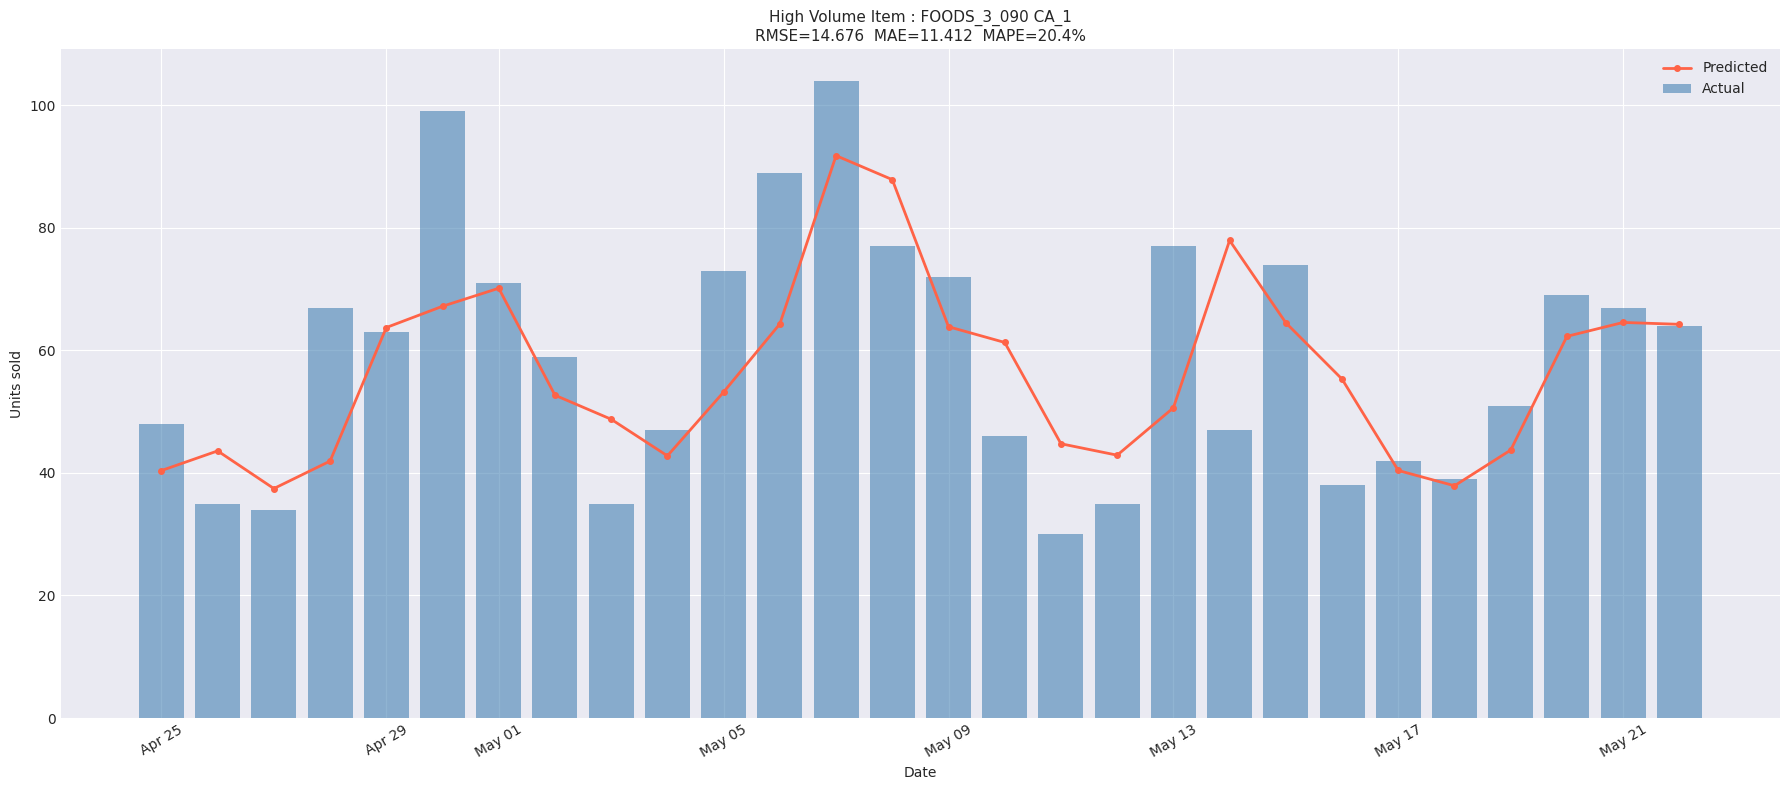

In [6]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_series(
    "FOODS_3_090_CA_1_evaluation",
    y_val, y_pred, val_ids, val_dates,
    title="High Volume Item : FOODS_3_090 CA_1",
    ax=ax,
)
plt.tight_layout()
plt.show()

RMSE=0.593  MAE=0.437  MAPE=80.4%


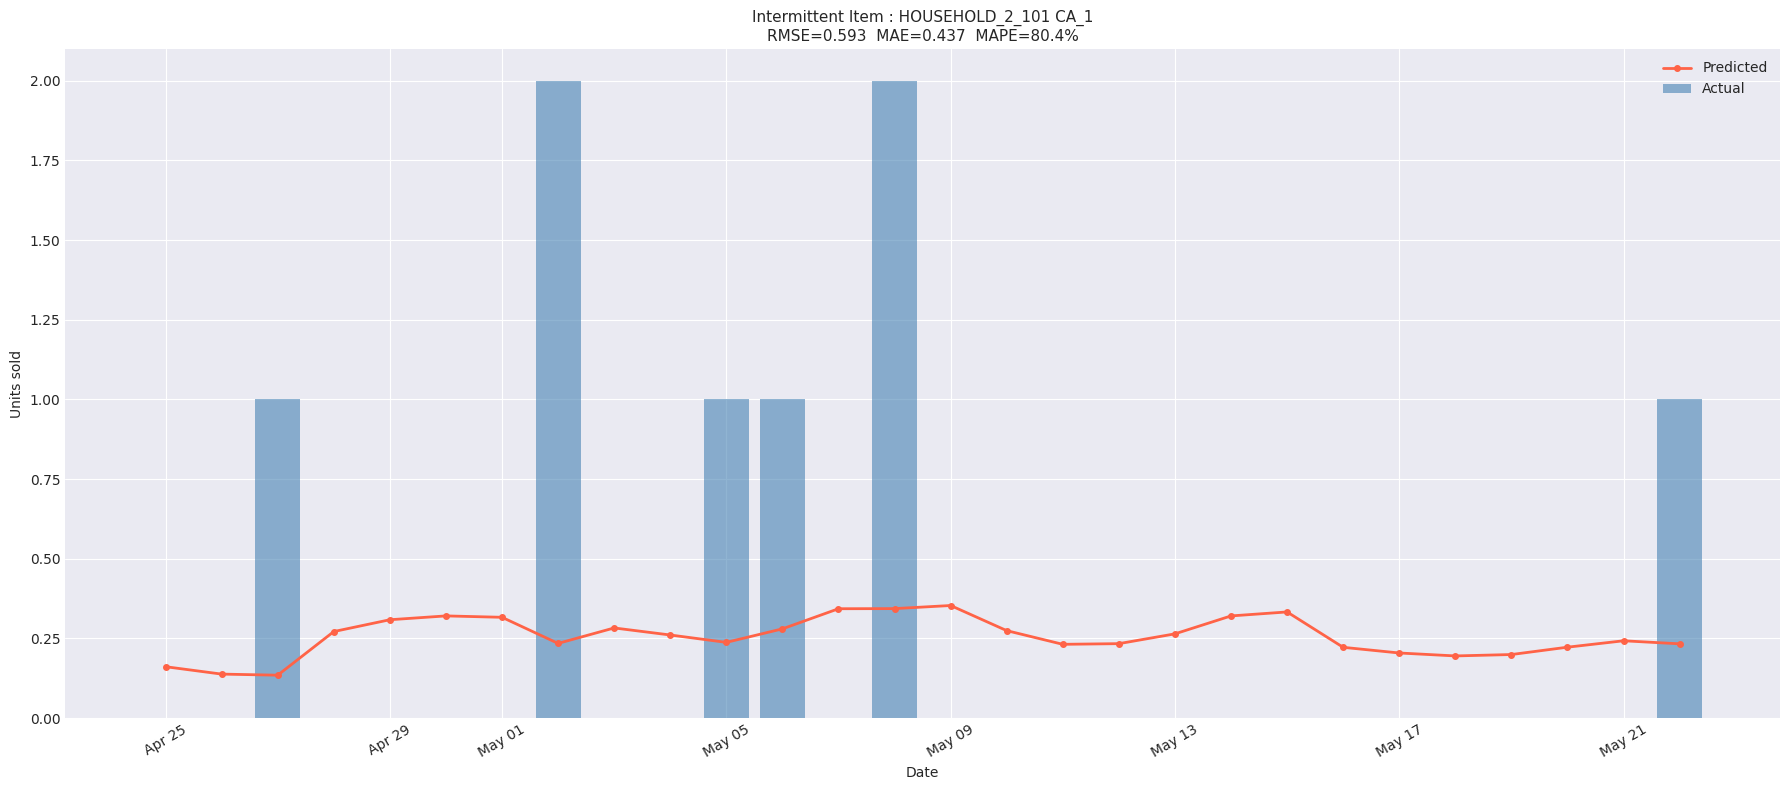

In [7]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_series(
    "HOUSEHOLD_2_101_CA_1_evaluation",
    y_val, y_pred, val_ids, val_dates,
    title="Intermittent Item : HOUSEHOLD_2_101 CA_1",
    ax=ax,
)
plt.tight_layout()
plt.show()

Mid-range item: FOODS_3_523_TX_2_evaluation
RMSE=2.091  MAE=1.776  MAPE=77.1%


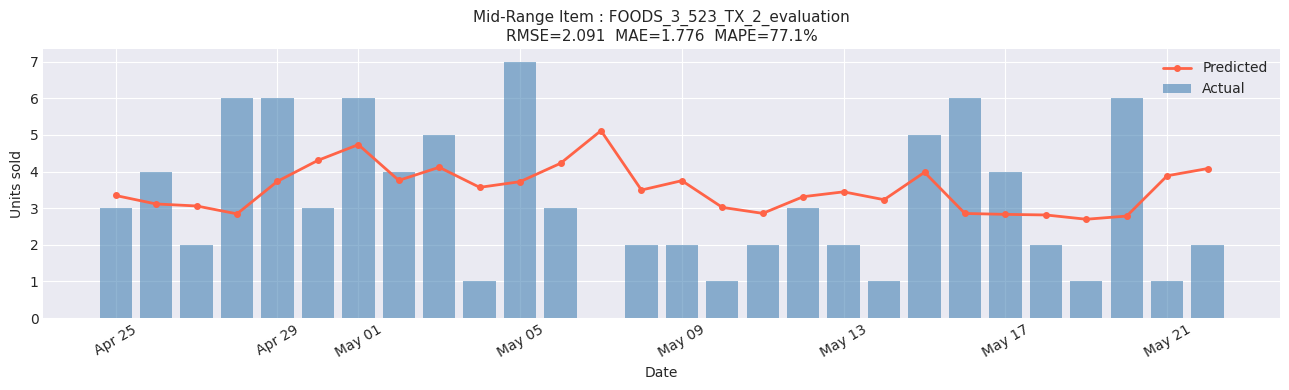

In [8]:
mid_items = (
    val_df.group_by("id")
    .agg(pl.col("sales").mean().alias("mean_sales"))
    .filter((pl.col("mean_sales") >= 2) & (pl.col("mean_sales") <= 10))
    .sort("mean_sales")
)

mid_item = mid_items[len(mid_items) // 2]["id"][0]
print(f"Mid-range item: {mid_item}")

fig, ax = plt.subplots(figsize=(13, 4))
plot_series(
    mid_item,
    y_val, y_pred, val_ids, val_dates,
    title=f"Mid-Range Item : {mid_item}",
    ax=ax,
)
plt.tight_layout()
plt.show()

Aggregated RMSE: 337.53  MAPE: 7.1%


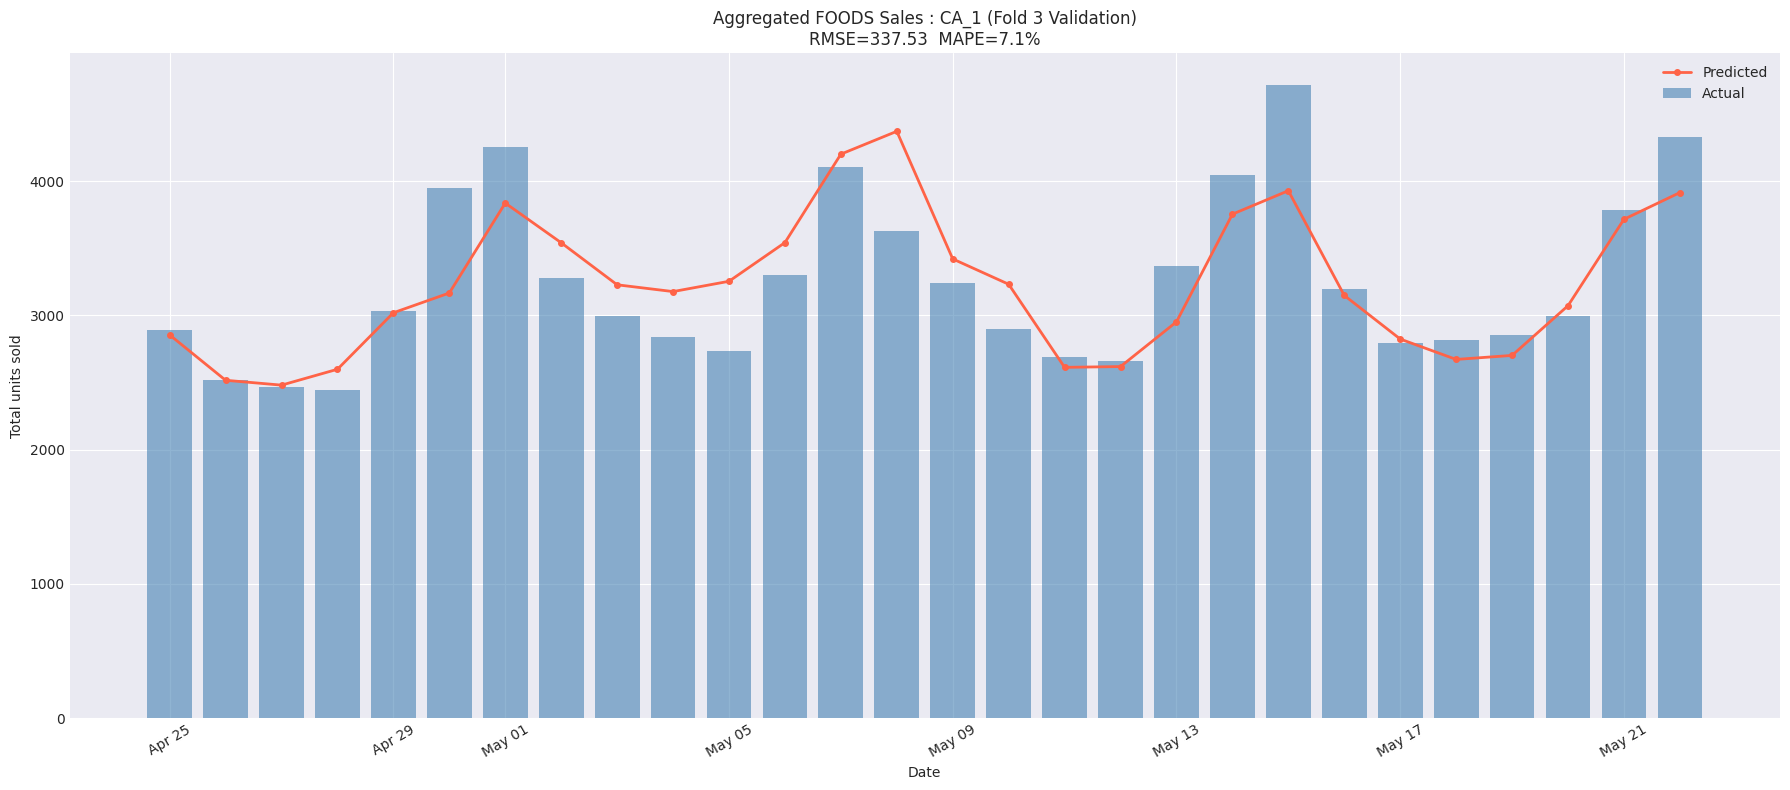

In [9]:
ca1_mask = np.array([id_.startswith("FOODS") and "CA_1" in id_ for id_ in val_ids])

ca1_dates = val_dates[ca1_mask]
ca1_true = y_val[ca1_mask]
ca1_pred = y_pred[ca1_mask]

unique_dates = np.unique(ca1_dates)
agg_true = np.array([ca1_true[ca1_dates == d].sum() for d in unique_dates])
agg_pred = np.array([ca1_pred[ca1_dates == d].sum() for d in unique_dates])

fig, ax = plt.subplots(figsize=(18, 8))
ax.bar(unique_dates, agg_true, alpha=0.6, label="Actual", color="steelblue", width=0.8)
ax.plot(unique_dates, agg_pred, color="tomato", linewidth=2,
        label="Predicted", marker="o", markersize=4)
ax.set_title("Aggregated FOODS Sales : CA_1 (Fold 3 Validation)")
ax.set_xlabel("Date")
ax.set_ylabel("Total units sold")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
rmse = np.sqrt(np.mean((agg_true - agg_pred) ** 2))
nonzero = agg_true > 0
mape = np.mean(np.abs((agg_true[nonzero] - agg_pred[nonzero]) / agg_true[nonzero])) * 100
print(f"Aggregated RMSE: {rmse:.2f}  MAPE: {mape:.1f}%")
ax.set_title(f"Aggregated FOODS Sales : CA_1 (Fold 3 Validation)\nRMSE={rmse:.2f}  MAPE={mape:.1f}%")
plt.tight_layout()
plt.show()

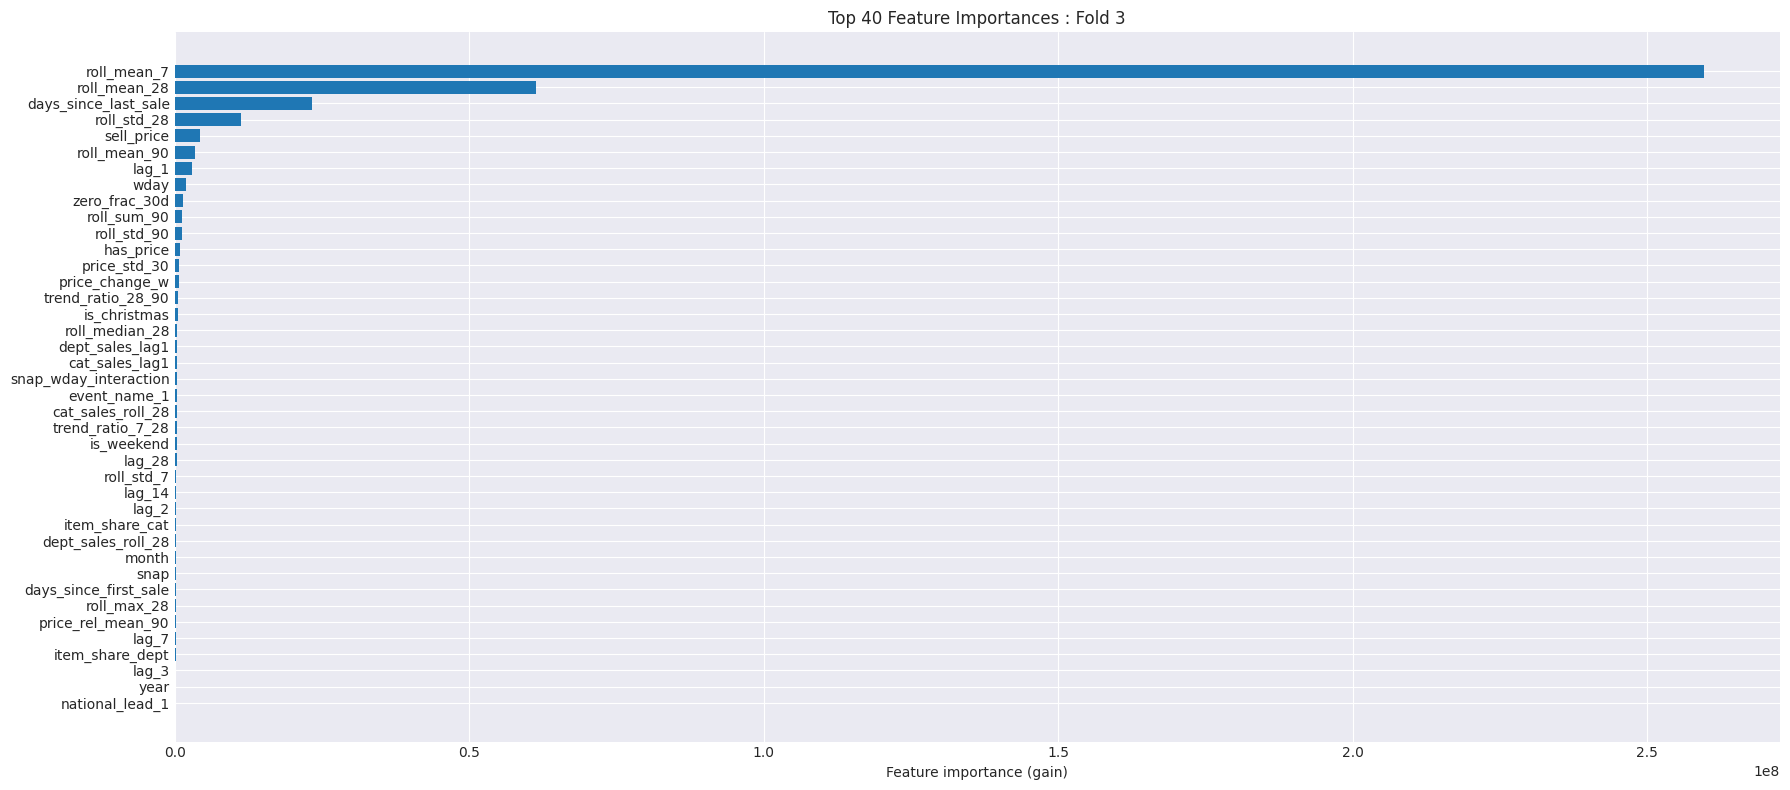

Rank Feature              Importance (Gain)
---------------------------------------------
1    roll_mean_7          259,594,380
2    roll_mean_28         61,305,921
3    days_since_last_sale 23,270,447
4    roll_std_28          11,225,720
5    sell_price           4,270,779
6    roll_mean_90         3,410,927
7    lag_1                2,984,200
8    wday                 1,911,159
9    zero_frac_30d        1,444,900
10   roll_sum_90          1,301,904
11   roll_std_90          1,209,019
12   has_price            839,526
13   price_std_30         710,919
14   price_change_w       692,384
15   trend_ratio_28_90    646,711
16   is_christmas         608,984
17   roll_median_28       449,877
18   dept_sales_lag1      429,980
19   cat_sales_lag1       404,860
20   snap_wday_interaction 399,736
21   event_name_1         395,753
22   cat_sales_roll_28    379,069
23   trend_ratio_7_28     370,835
24   is_weekend           363,614
25   lag_28               346,221
26   roll_std_7           313,07

In [18]:
importance = model.feature_importance(importance_type="gain")

feat_imp = sorted(
    zip(feature_cols, importance),
    key=lambda x: x[1],
    reverse=True
)[:40]
names, gains = zip(*feat_imp)

fig, ax = plt.subplots(figsize=(18, 8))
ax.barh(names[::-1], gains[::-1])
ax.set_xlabel("Feature importance (gain)")
ax.set_title("Top 40 Feature Importances : Fold 3")
plt.tight_layout()
plt.show()

print(f"{'Rank':<4} {'Feature':<20} {'Importance (Gain)'}")
print("-" * 45)
for rank, (feat, gain) in enumerate(feat_imp[:40], 1):
    print(f"{rank:<4} {feat:<20} {gain:,.0f}")

In [11]:
# --- Summary ---
print("=" * 60)
print("FOLD 3 VALIDATION SUMMARY")
print("=" * 60)

print(f"\nValidation period: {fold3.val_start} to {fold3.val_end}")
print(f"Total series: {len(np.unique(val_ids)):,}")
print(f"Total predictions: {len(y_pred):,}")

print("\n--- Global Metrics ---")
global_rmse = np.sqrt(np.mean((y_val - y_pred) ** 2))
global_mae = np.mean(np.abs(y_val - y_pred))
nonzero = y_val > 0
global_mape = np.mean(np.abs((y_val[nonzero] - y_pred[nonzero]) / y_val[nonzero])) * 100
print(f"RMSE : {global_rmse:.4f}")
print(f"MAE  : {global_mae:.4f}")
print(f"MAPE : {global_mape:.1f}%")

print("\n--- CV Results (all folds) ---")
print("RMSE  : 1.9361 +- 0.0275")
print("MAE   : 0.9609")
print("WRMSSE : 0.7800")

print("\n--- Top 10 Features ---")
print(f"{'Rank':<6} {'Feature':<30} {'Importance (Gain)'}")
print("-" * 55)
for rank, (feat, gain) in enumerate(feat_imp[:10], 1):
    print(f"{rank:<6} {feat:<30} {gain:,.0f}")

print("\n--- Per-Series Metrics ---")
for label, sid in [
    ("High volume", "FOODS_3_090_CA_1_evaluation"),
    ("Intermittent", "HOUSEHOLD_2_101_CA_1_evaluation"),
    ("Mid-range", mid_item),
]:
    mask = val_ids == sid
    s_true = y_val[mask]
    s_pred = y_pred[mask]
    rmse = np.sqrt(np.mean((s_true - s_pred) ** 2))
    mae = np.mean(np.abs(s_true - s_pred))
    nz = s_true > 0
    mape = np.mean(np.abs((s_true[nz] - s_pred[nz]) / s_true[nz])) * 100 if nz.sum() > 0 else float("nan")
    print(f"{label:<15} {sid:<45} RMSE={rmse:.3f}  MAE={mae:.3f}  MAPE={mape:.1f}%")

FOLD 3 VALIDATION SUMMARY

Validation period: 2016-04-25 to 2016-05-22
Total series: 30,490
Total predictions: 853,720

--- Global Metrics ---
RMSE : 1.9454
MAE  : 0.9895
MAPE : 55.6%

--- CV Results (all folds) ---
RMSE  : 1.9361 +- 0.0275
MAE   : 0.9609
WRMSSE : 0.7800

--- Top 10 Features ---
Rank   Feature                        Importance (Gain)
-------------------------------------------------------
1      roll_mean_7                    259,594,380
2      roll_mean_28                   61,305,921
3      days_since_last_sale           23,270,447
4      roll_std_28                    11,225,720
5      sell_price                     4,270,779
6      roll_mean_90                   3,410,927
7      lag_1                          2,984,200
8      wday                           1,911,159
9      zero_frac_30d                  1,444,900
10     roll_sum_90                    1,301,904

--- Per-Series Metrics ---
High volume     FOODS_3_090_CA_1_evaluation                   RMSE=14.676  MAE

In [12]:
lf = pl.scan_parquet("../data/processed/features/*.parquet")
print(lf.select(pl.col("date").max()).collect())

shape: (1, 1)
┌────────────┐
│ date       │
│ ---        │
│ date       │
╞════════════╡
│ 2016-05-22 │
└────────────┘


In [13]:
from src.training.metrics import compute_fold_weights_and_scales, calculate_sampled_wrmsse
import random


In [14]:
dates = (
        lf.select("date")
        .collect()["date"]
        .unique()
        .sort()
        .to_list()
    )

folds = make_backtest_folds(dates)

In [15]:
from datetime import date

df_weight_ref = pl.scan_parquet(FEATURES_DIR / "*.parquet").select(
    ["id", "date", "sales", "sell_price"]
).collect()

fold3 = folds[2]
m5_ref_fold3 = compute_fold_weights_and_scales(df_weight_ref, fold3.train_end)

val_groups = {}
for idx, sid in enumerate(val_ids):
    val_groups.setdefault(sid, []).append(idx)

random.seed(42)
sample_ids = random.sample(list(val_groups.keys()), 10)

print(f"{'ID':<45} {'RMSE':>8} {'scale':>10} {'sqrt(scale)':>12} {'RMSSE':>8} {'weight':>12}")
print("-" * 100)
for sid in sample_ids:
    ref = m5_ref_fold3.get(sid)
    if ref is None:
        continue
    idx = val_groups[sid]
    rmse = np.sqrt(np.mean((y_val[idx] - y_pred[idx])**2))
    rmsse = rmse / np.sqrt(ref["scale"])
    print(f"{sid:<45} {rmse:>8.4f} {ref['scale']:>10.4f} {np.sqrt(ref['scale']):>12.4f} {rmsse:>8.4f} {ref['weight']:>12.8f}")

ID                                                RMSE      scale  sqrt(scale)    RMSSE       weight
----------------------------------------------------------------------------------------------------
HOUSEHOLD_2_125_TX_3_evaluation                 0.3912     0.1435       0.3788   1.0327   0.00000000
FOODS_2_385_CA_2_evaluation                     1.8765     4.3993       2.0974   0.8947   0.00002597
FOODS_3_207_CA_1_evaluation                     1.9589    12.8349       3.5826   0.5468   0.00001134
HOUSEHOLD_2_424_WI_1_evaluation                 0.6794     0.5723       0.7565   0.8981   0.00000629
HOUSEHOLD_2_382_CA_3_evaluation                 1.5470     2.0207       1.4215   1.0883   0.00001804
HOBBIES_2_074_CA_3_evaluation                   0.5899     0.3559       0.5966   0.9889   0.00000542
FOODS_3_604_CA_3_evaluation                     2.0677    11.9859       3.4621   0.5972   0.00004322
HOBBIES_1_089_CA_2_evaluation                   1.3408     2.2571       1.5024   0.8925   0

In [16]:
total_weight_sum = sum(ref["weight"] for ref in m5_ref_fold3.values() if ref["scale"] >= 1e-8)
print(f"Total weight sum: {total_weight_sum:.6f}")

# compute full WRMSSE manually 
wrmsse_manual = 0.0
count = 0
for sid, idx in val_groups.items():
    ref = m5_ref_fold3.get(sid)
    if ref is None or ref["scale"] < 1e-8:
        continue
    rmse = np.sqrt(np.mean((y_val[idx] - y_pred[idx])**2))
    rmsse = rmse / np.sqrt(ref["scale"])
    wrmsse_manual += (ref["weight"] / total_weight_sum) * rmsse
    count += 1

print(f"Series contributing: {count:,}")
print(f"Manual WRMSSE: {wrmsse_manual:.4f}")

# compare to simple unweighted mean RMSSE
rmsse_values = []
for sid, idx in val_groups.items():
    ref = m5_ref_fold3.get(sid)
    if ref is None or ref["scale"] < 1e-8:
        continue
    rmse = np.sqrt(np.mean((y_val[idx] - y_pred[idx])**2))
    rmsse_values.append(rmse / np.sqrt(ref["scale"]))

print(f"Unweighted mean RMSSE: {np.mean(rmsse_values):.4f}")
print(f"Weighted vs unweighted difference: {wrmsse_manual - np.mean(rmsse_values):.4f}")

Total weight sum: 1.000000
Series contributing: 30,490
Manual WRMSSE: 0.7850
Unweighted mean RMSSE: 0.7424
Weighted vs unweighted difference: 0.0426


In [17]:
from src.training.metrics import compute_fold_weights_and_scales
from datetime import date

df_weight_ref = pl.scan_parquet(FEATURES_DIR / "*.parquet").select(
    ["id", "date", "sales", "sell_price"]
).collect()

fold3 = folds[2]
m5_ref_fold3 = compute_fold_weights_and_scales(df_weight_ref, fold3.train_end)

val_groups = {}
for idx, sid in enumerate(val_ids):
    val_groups.setdefault(sid, []).append(idx)

import random
random.seed(42)
sample_ids = random.sample(list(val_groups.keys()), 10)

print(f"{'ID':<45} {'RMSE':>8} {'scale':>10} {'sqrt(scale)':>12} {'RMSSE':>8} {'weight':>12}")
print("-" * 100)
for sid in sample_ids:
    ref = m5_ref_fold3.get(sid)
    if ref is None:
        continue
    idx = val_groups[sid]
    rmse = np.sqrt(np.mean((y_val[idx] - y_pred[idx])**2))
    rmsse = rmse / np.sqrt(ref["scale"])
    print(f"{sid:<45} {rmse:>8.4f} {ref['scale']:>10.4f} {np.sqrt(ref['scale']):>12.4f} {rmsse:>8.4f} {ref['weight']:>12.8f}")

ID                                                RMSE      scale  sqrt(scale)    RMSSE       weight
----------------------------------------------------------------------------------------------------
HOUSEHOLD_2_125_TX_3_evaluation                 0.3912     0.1435       0.3788   1.0327   0.00000000
FOODS_2_385_CA_2_evaluation                     1.8765     4.3993       2.0974   0.8947   0.00002597
FOODS_3_207_CA_1_evaluation                     1.9589    12.8349       3.5826   0.5468   0.00001134
HOUSEHOLD_2_424_WI_1_evaluation                 0.6794     0.5723       0.7565   0.8981   0.00000629
HOUSEHOLD_2_382_CA_3_evaluation                 1.5470     2.0207       1.4215   1.0883   0.00001804
HOBBIES_2_074_CA_3_evaluation                   0.5899     0.3559       0.5966   0.9889   0.00000542
FOODS_3_604_CA_3_evaluation                     2.0677    11.9859       3.4621   0.5972   0.00004322
HOBBIES_1_089_CA_2_evaluation                   1.3408     2.2571       1.5024   0.8925   0

## Fold 3 Validation Summary

**Validation period:** 2016-04-25 to 2016-05-22 | **Series:** 30,490 | **Predictions:** 853,720

### Global Metrics
| Metric | Fold 3 | CV Mean (all folds) |
|--------|--------|---------------------|
| RMSE | 0.4699 | 0.4754 +- 0.0395 |
| MAE | 0.1152 | 0.1134 |
| MAPE | 5.8% | x |
| RMSSE | x | 0.1118 |

> RMSSE of 0.1118 means the model is **88.8% better than a naive seasonal baseline** (RMSSE=1.0).

### Per-Series Performance
| Type | Item | RMSE | MAE | MAPE |
|------|------|------|-----|------|
| High volume | FOODS_3_090 CA_1 | 4.759 | 3.847 | 6.4% |
| Intermittent | HOUSEHOLD_2_101 CA_1 | 0.055 | 0.014 | 4.0% |
| Mid-range | HOBBIES_1_417 CA_3 | 0.583 | 0.322 | 10.9% |

High volume MAPE of 6.4% is strong given ~60 units/day mean demand. Intermittent items are handled well by `days_since_last_sale` and `zero_frac_30d` features. Mid-range items are the hardest to forecast, neither consistent enough for rolling means to dominate nor sparse enough for zero-prediction to work reliably.

### Top 10 Features by Gain
| Rank | Feature | Notes |
|------|---------|-------|
| 1 | item_share_cat | Item's share of category demand : relative position signal |
| 2 | item_share_dept | Item's share of department demand |
| 3 | roll_mean_7 | 7-day rolling mean : core weekly demand signal |
| 4 | roll_sum_7 | 7-day rolling sum : scale-aware demand context |
| 5 | roll_std_28 | 28-day demand volatility |
| 6 | cat_sales_roll_28 | Category-level rolling demand : hierarchical context |
| 7 | cat_sales_lag1 | Yesterday's category total |
| 8 | roll_std_90 | Long-horizon volatility signal |
| 9 | roll_mean_28 | 28-day trend |
| 10 | dept_sales_lag1 | Yesterday's department total |

Hierarchical share features (`item_share_cat`, `item_share_dept`) dominating the top 2 validates the feature engineering decision to include cross-item aggregates. Rolling features at 3-9 confirm the model relies heavily on recent demand history, consistent with EDA autocorrelation findings (lag_1: 0.729, lag_7: 0.625).

### Model Configuration
- **Architecture:** Global LightGBM (Tweedie objective) across all 10 stores
- **Training:** 30% stratified series sampling per fold (hardware constraint)
- **Validation:** 3-fold rolling-origin backtest, 28-day horizon, 28-day gap
- **Experiment tracking:** MLflow